# GP Regression — Tactile Sensor Force Prediction
- 입력: 3×3 센서 9개값
- 출력: force (N) + 불확실성
- kernel: Matérn(ν=2.5)

In [1]:
import numpy as np
from pathlib import Path
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

K = 5  # 사용할 상위 센서값 개수: 1~9

In [2]:
import os
for f in os.listdir('../Tactile_sensor_training_data'):
    print(f)

tac_finger_l_sensor1_7N.npz
tac_finger_l_sensor1_13N.npz
tac_finger_l_sensor1_10N.npz
tac_finger_l_sensor1_17N.npz
tac_finger_l_sensor1_20N.npz
tac_finger_l_sensor1_15N.npz
tac_finger_l_sensor1_5N.npz


In [3]:
from pathlib import Path
for f in Path('../Tactile_sensor_training_data').glob('*.npz'):
    print(f.stem, f.stem.split('_')[-1])

tac_finger_l_sensor1_7N 7N
tac_finger_l_sensor1_13N 13N
tac_finger_l_sensor1_10N 10N
tac_finger_l_sensor1_17N 17N
tac_finger_l_sensor1_20N 20N
tac_finger_l_sensor1_15N 15N
tac_finger_l_sensor1_5N 5N


## 1. 데이터 로드

In [4]:
def load_data(folder_path):
    """
    파일명에서 force 레이블 파싱, 9개 센서값 전부 사용
    Returns: X (N, 9), y (N,)
    """
    folder = Path(folder_path)
    X_list, y_list = [], []

    for npz_file in sorted(folder.glob('*.npz')):
        # 파일명에서 force 파싱 (예: tac_finger_r_sensor1_10N.npz → 10)
        force_str = npz_file.stem.split('_')[-1].replace('N', '')
        force = int(force_str)

        data = np.load(npz_file)
        arr = data['arr_0']  # shape: (samples, 9)

        # top-K 센서값 사용
        x_top5 = np.partition(arr, -K, axis=1)[:, -K:]
        X_list.append(x_top5)       # (samples, K)
        y_list.append(np.full(len(arr), force))

    X = np.vstack(X_list)   # (total_samples, K)
    y = np.concatenate(y_list)  # (total_samples,)

    print(f'X shape: {X.shape}, y shape: {y.shape}')
    print(f'Force levels: {np.unique(y)}')
    return X, y

# 경로 수정
X, y = load_data('../Tactile_sensor_training_data')

print('\nX sample:')
print(X[:3])
print('y sample:', y[:6])

X shape: (70, 5), y shape: (70,)
Force levels: [ 5  7 10 13 15 17 20]

X sample:
[[ 12.  27.  51.  72. 105.]
 [  0.  15.  23.  76. 110.]
 [  9.  49.  58.  82.  90.]]
y sample: [10 10 10 10 10 10]


## 2. 전처리

In [5]:
from sklearn.preprocessing import StandardScaler
# 센서값 정규화 (GP는 스케일에 민감)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('정규화 전 mean/std:', X.mean().round(2), X.std().round(2))
print('정규화 후 mean/std:', X_scaled.mean().round(4), X_scaled.std().round(4))

정규화 전 mean/std: 73.87 55.18
정규화 후 mean/std: 0.0 1.0


## 3. GP 모델 정의

- `Matern(nu=2.5)`: 촉각 센서처럼 약간 거친 데이터에 적합
- `WhiteKernel`: 노이즈 항 (센서 측정 노이즈 반영)
- `n_restarts_optimizer=10`: 하이퍼파라미터 최적화를 10번 다른 초기값으로 시도

In [6]:
kernel = Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1.0)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True,   # y도 내부적으로 정규화
    random_state=42
)

gpr.fit(X_scaled, y)

print('학습 완료')
print(f'최적화된 kernel: {gpr.kernel_}')
print(f'  → ℓ (lengthscale): {gpr.kernel_.k1.length_scale:.4f}')
print(f'  → noise level: {gpr.kernel_.k2.noise_level:.4f}')

import joblib
joblib.dump(gpr, 'gp_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
import json
with open('gp_config.json', 'w', encoding='utf-8') as f:
    json.dump({'k': K, 'sort_top_k': False}, f, indent=2)
print('모델 저장 완료')

학습 완료
최적화된 kernel: Matern(length_scale=6.64, nu=2.5) + WhiteKernel(noise_level=0.0199)
  → ℓ (lengthscale): 6.6378
  → noise level: 0.0199
모델 저장 완료


## 4. 평가 — Leave-One-Out Cross Validation
데이터 15개라 train/test split 의미없음 → LOO 사용

In [7]:
loo = LeaveOneOut()
y_pred_loo = np.zeros(len(y))
y_std_loo  = np.zeros(len(y))

for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train = y[train_idx]

    gpr_loo = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=5,
        normalize_y=True,
        random_state=42
    )
    gpr_loo.fit(X_train, y_train)
    mu, std = gpr_loo.predict(X_test, return_std=True)
    y_pred_loo[test_idx] = mu
    y_std_loo[test_idx]  = std

rmse = np.sqrt(mean_squared_error(y, y_pred_loo))
mae  = mean_absolute_error(y, y_pred_loo)

print(f'LOO RMSE: {rmse:.3f} N')
print(f'LOO MAE:  {mae:.3f} N')
print()
print(f'{"실제":>6} {"예측":>8} {"불확실성":>10} {"오차":>8}')
print('-' * 40)
for gt, pred, std in zip(y, y_pred_loo, y_std_loo):
    print(f'{gt:>6.0f}N {pred:>7.2f}N ±{std:>7.2f}N {abs(gt-pred):>7.2f}N')

LOO RMSE: 0.774 N
LOO MAE:  0.620 N

    실제       예측       불확실성       오차
----------------------------------------
    10N   10.25N ±   0.76N    0.25N
    10N    9.50N ±   0.84N    0.50N
    10N   10.33N ±   0.76N    0.33N
    10N   10.24N ±   0.79N    0.24N
    10N   11.15N ±   0.73N    1.15N
    10N   11.85N ±   0.72N    1.85N
    10N   11.13N ±   0.73N    1.13N
    10N    9.70N ±   0.82N    0.30N
    10N   11.00N ±   0.73N    1.00N
    10N   11.16N ±   0.73N    1.16N
    13N   11.34N ±   0.72N    1.66N
    13N   11.50N ±   0.73N    1.50N
    13N   11.76N ±   0.74N    1.24N
    13N   13.02N ±   0.76N    0.02N
    13N   13.82N ±   0.80N    0.82N
    13N   12.43N ±   0.78N    0.57N
    13N   11.91N ±   0.75N    1.09N
    13N   12.75N ±   0.74N    0.25N
    13N   12.82N ±   0.75N    0.18N
    13N   12.46N ±   0.75N    0.54N
    15N   15.77N ±   0.75N    0.77N
    15N   15.97N ±   0.75N    0.97N
    15N   15.97N ±   0.75N    0.97N
    15N   16.27N ±   0.79N    1.27N
    15N   15.39N ±   0

## 5. 전체 데이터로 학습한 모델로 예측 시각화

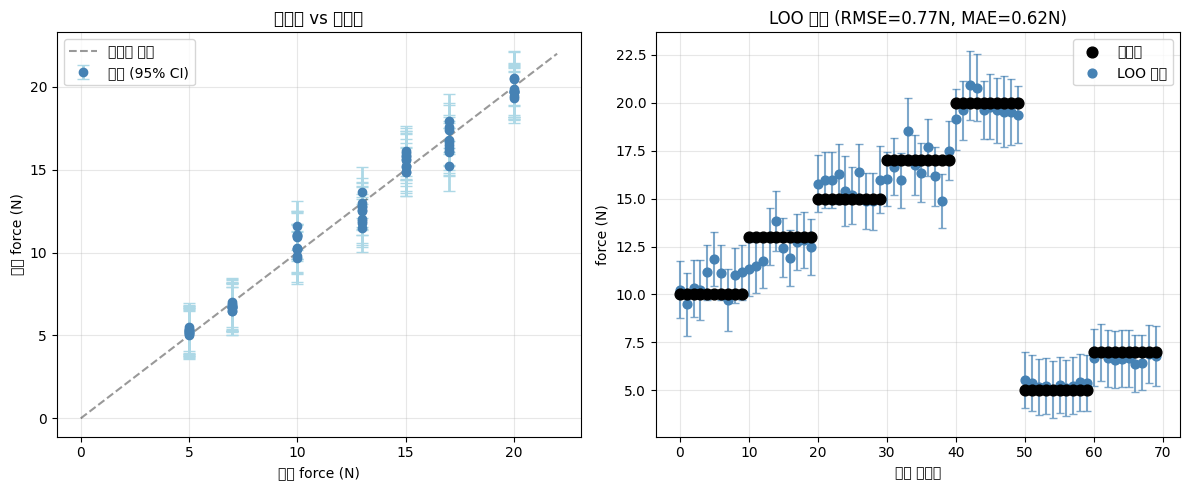

gp_result.png 저장 완료


In [8]:
y_pred_all, y_std_all = gpr.predict(X_scaled, return_std=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 예측값 vs 실제값
ax = axes[0]
ax.errorbar(y, y_pred_all, yerr=y_std_all*1.96,
            fmt='o', color='steelblue', ecolor='lightblue',
            elinewidth=2, capsize=4, label='예측 (95% CI)')
ax.plot([0, 22], [0, 22], 'k--', alpha=0.4, label='완벽한 예측')
ax.set_xlabel('실제 force (N)')
ax.set_ylabel('예측 force (N)')
ax.set_title('예측값 vs 실제값')
ax.legend()
ax.grid(True, alpha=0.3)

# LOO 불확실성
ax = axes[1]
colors = plt.cm.RdYlGn_r(y_std_loo / y_std_loo.max())
scatter = ax.scatter(range(len(y)), y, c='black', zorder=5, label='실제값', s=60)
ax.errorbar(range(len(y)), y_pred_loo, yerr=y_std_loo*1.96,
            fmt='none', ecolor='steelblue', elinewidth=1.5, capsize=3, alpha=0.7)
ax.scatter(range(len(y)), y_pred_loo, c='steelblue', zorder=4, label='LOO 예측', s=40)
ax.set_xlabel('샘플 인덱스')
ax.set_ylabel('force (N)')
ax.set_title(f'LOO 예측 (RMSE={rmse:.2f}N, MAE={mae:.2f}N)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gp_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('gp_result.png 저장 완료')

## 6. 새 데이터 예측 (inference)
스케일 변환해서 사용해서, 사용할 때 스케일러 로드해서 사용

In [10]:
import joblib

gpr = joblib.load('gp_model.pkl')
scaler = joblib.load('scaler.pkl')

def predict_force(npz_path):
    data = np.load(npz_path)
    arr = data['arr_0']  # (samples, 9)

    x_top5 = np.partition(arr, -K, axis=1)[:, -K:]
    arr_scaled = scaler.transform(x_top5)

    mu, std = gpr.predict(arr_scaled, return_std=True)

    print(f'파일: {npz_path}')
    for i, (m, s) in enumerate(zip(mu, std)):
        print(f'  sample {i+1}: {m:.2f}N ± {s:.2f}N (95% CI: [{m-1.96*s:.2f}, {m+1.96*s:.2f}]N)')

predict_force('../Tactile_sensor_training_data/tac_finger_l_sensor1_5N.npz')

파일: ../Tactile_sensor_training_data/tac_finger_l_sensor1_5N.npz
  sample 1: 5.50N ± 0.74N (95% CI: [4.05, 6.94]N)
  sample 2: 5.34N ± 0.74N (95% CI: [3.89, 6.78]N)
  sample 3: 5.15N ± 0.74N (95% CI: [3.70, 6.59]N)
  sample 4: 5.21N ± 0.73N (95% CI: [3.77, 6.65]N)
  sample 5: 5.02N ± 0.75N (95% CI: [3.56, 6.48]N)
  sample 6: 5.25N ± 0.73N (95% CI: [3.81, 6.69]N)
  sample 7: 5.10N ± 0.74N (95% CI: [3.65, 6.55]N)
  sample 8: 5.23N ± 0.74N (95% CI: [3.77, 6.68]N)
  sample 9: 5.38N ± 0.74N (95% CI: [3.93, 6.83]N)
  sample 10: 5.36N ± 0.74N (95% CI: [3.91, 6.80]N)
